In [11]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from scipy.stats import norm
from pathlib import Path

In [12]:
PROJECT_ROOT = Path.cwd().parent

DATA = PROJECT_ROOT / "data"

HISTORICAL = DATA / "historical"
OPTIONS = DATA / "options"
REPORT = PROJECT_ROOT / "report"

print(PROJECT_ROOT)

c:\Users\Intern Batch 2\Documents\SPY_Options_Project


In [13]:
spy = pd.read_csv(
    HISTORICAL / "SPY_1Y.csv",
    skiprows=[1]
)

numeric_cols = [
    "Close",
    "High",
    "Low",
    "Open",
    "Volume"
]

spy[numeric_cols] = spy[numeric_cols].apply(
    pd.to_numeric
)

spy.head()

,Close,High,Low,Open,Volume
0,625.845459,626.498200,621.246394,622.156295,64357500
1,625.321228,629.999373,622.215625,629.267492,74205800
2,630.197205,630.662085,626.794901,627.111401,64051600
3,628.951050,631.947874,627.704848,630.474212,58742300
4,635.646851,635.805071,629.811484,631.295045,64730800


In [14]:
calls = pd.read_csv(
    OPTIONS / "SPY_Calls.csv"
)

calls.head()

,contractSymbol,lastTradeDate,strike,lastPrice,bid,ask,change,percentChange,volume,openInterest,impliedVolatility,inTheMoney,contractSize,currency
0,SPY260806C00630000,2026-08-05 18:08:22+00:00,630.0,141.86,0.0,0.0,0.0,0.0,1.0,1,0.00001,True,REGULAR,USD
1,SPY260806C00675000,2026-07-30 14:47:04+00:00,675.0,63.40,0.0,0.0,0.0,0.0,NaN,0,0.00001,True,REGULAR,USD
2,SPY260806C00680000,2026-08-05 19:59:32+00:00,680.0,90.70,0.0,0.0,0.0,0.0,10.0,8,0.00001,True,REGULAR,USD
3,SPY260806C00685000,2026-07-27 15:32:15+00:00,685.0,54.90,0.0,0.0,0.0,0.0,1.0,1,0.00001,True,REGULAR,USD
4,SPY260806C00700000,2026-08-03 14:23:19+00:00,700.0,54.45,0.0,0.0,0.0,0.0,2.0,1,0.00001,True,REGULAR,USD


In [15]:
spy_price = spy["Close"].iloc[-1]

print(f"Current SPY Price = {spy_price:.2f}")

Current SPY Price = 769.79


In [16]:
returns = np.log(
    spy["Close"] /
    spy["Close"].shift(1)
)

hv = (
    returns
    .rolling(20)
    .std()
    .iloc[-1]
    * np.sqrt(252)
)

print(f"Historical Volatility = {hv:.2%}")

Historical Volatility = 14.47%


In [17]:
calls["Distance"] = abs(
    calls["strike"] - spy_price
)

atm = calls.loc[
    calls["Distance"].idxmin()
]

atm

contractSymbol              SPY260806C00770000
lastTradeDate        2026-08-05 20:14:59+00:00
strike                                   770.0
lastPrice                                 2.74
bid                                        0.0
ask                                        0.0
change                                     0.0
percentChange                              0.0
volume                                 19182.0
openInterest                              6232
impliedVolatility                     0.001963
inTheMoney                               False
contractSize                           REGULAR
currency                                   USD
Distance                              0.210022
Name: 63, dtype: object

In [18]:
S = spy_price

K = atm["strike"]

market_price = atm["lastPrice"]

sigma = atm["impliedVolatility"]

T = 7 / 365

r = 0.04

bid = atm["bid"]

ask = atm["ask"]

volume = atm["volume"]

open_interest = atm["openInterest"]

spread = ask - bid

In [19]:
def black_scholes_call(
    S,
    K,
    T,
    r,
    sigma
):

    d1 = (
        np.log(S / K)
        +
        (r + sigma**2 / 2) * T
    ) / (
        sigma * np.sqrt(T)
    )

    d2 = d1 - sigma * np.sqrt(T)

    return (
        S * norm.cdf(d1)
        -
        K * np.exp(-r * T) * norm.cdf(d2)
    )

In [20]:
theoretical_price = black_scholes_call(
    S,
    K,
    T,
    r,
    sigma
)

pricing_error = (
    market_price -
    theoretical_price
)

print(theoretical_price)
print(pricing_error)

0.3832882460038718
2.3567117539961284


In [21]:
d1 = (
    np.log(S / K)
    +
    (r + sigma**2 / 2) * T
) / (
    sigma * np.sqrt(T)
)

d2 = d1 - sigma * np.sqrt(T)

call_delta = norm.cdf(d1)

gamma = (
    norm.pdf(d1)
    /
    (
        S
        * sigma
        * np.sqrt(T)
    )
)

vega = (
    S
    * norm.pdf(d1)
    * np.sqrt(T)
    / 100
)

theta = (
    (
        -S
        * norm.pdf(d1)
        * sigma
        /
        (2 * np.sqrt(T))
    )
    -
    (
        r
        * K
        * np.exp(-r * T)
        * norm.cdf(d2)
    )
) / 365

rho = (
    K
    * T
    * np.exp(-r * T)
    * norm.cdf(d2)
    / 100
)

In [22]:
summary = pd.DataFrame({

    "Metric":[

        "SPY Price",
        "Strike",
        "Market Price",
        "Theoretical Price",
        "Pricing Error",
        "Historical Volatility",
        "Implied Volatility",
        "Delta",
        "Gamma",
        "Vega",
        "Theta",
        "Rho",
        "Volume",
        "Open Interest",
        "Bid",
        "Ask",
        "Bid-Ask Spread"

    ],

    "Value":[

        S,
        K,
        market_price,
        theoretical_price,
        pricing_error,
        hv,
        sigma,
        call_delta,
        gamma,
        vega,
        theta,
        rho,
        volume,
        open_interest,
        bid,
        ask,
        spread

    ]

})

summary

,Metric,Value
0,SPY Price,769.789978
1,Strike,770.000000
2,Market Price,2.740000
3,Theoretical Price,0.383288
4,Pricing Error,2.356712
5,Historical Volatility,0.144729
6,Implied Volatility,0.001963
7,Delta,0.965503
8,Gamma,0.364864
9,Vega,0.081400


In [23]:
summary.to_csv(

    REPORT /
    "SPY_Option_Summary.csv",

    index=False

)

print("Saved")

Saved


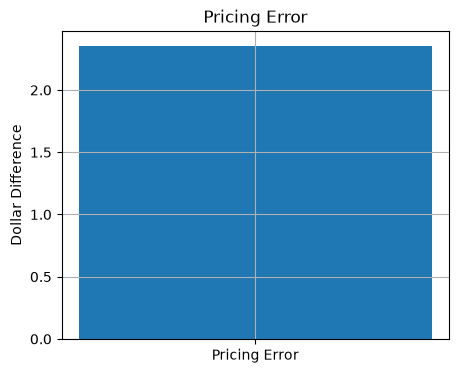

In [24]:
plt.figure(figsize=(5,4))

plt.bar(

    ["Pricing Error"],

    [pricing_error]

)

plt.ylabel("Dollar Difference")

plt.title("Pricing Error")

plt.grid()

plt.savefig(

    REPORT /
    "Pricing_Error.png",

    dpi=300,

    bbox_inches="tight"

)

plt.show()

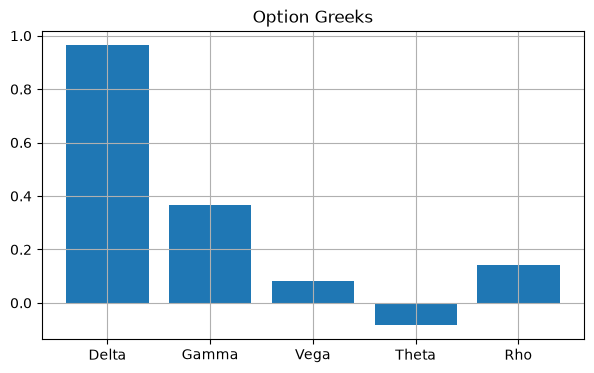

In [25]:
greeks = {

    "Delta":call_delta,

    "Gamma":gamma,

    "Vega":vega,

    "Theta":theta,

    "Rho":rho

}

plt.figure(figsize=(7,4))

plt.bar(

    greeks.keys(),

    greeks.values()

)

plt.title("Option Greeks")

plt.grid()

plt.savefig(

    REPORT /
    "Greeks.png",

    dpi=300,

    bbox_inches="tight"

)

plt.show()

In [26]:
print("----------- SPY OPTION ANALYSIS -----------\n")

print(f"Current SPY Price       : {S:.2f}")
print(f"Strike Price            : {K:.2f}")

print()

print(f"Market Price            : {market_price:.2f}")
print(f"Theoretical Price       : {theoretical_price:.2f}")
print(f"Pricing Error           : {pricing_error:.4f}")

print()

print(f"Historical Volatility   : {hv*100:.2f}%")
print(f"Implied Volatility      : {sigma*100:.2f}%")

print()

print(f"Delta                   : {call_delta:.4f}")
print(f"Gamma                   : {gamma:.6f}")
print(f"Vega                    : {vega:.4f}")
print(f"Theta                   : {theta:.4f}")
print(f"Rho                     : {rho:.4f}")

print()

print(f"Volume                  : {volume}")
print(f"Open Interest           : {open_interest}")
print(f"Bid                     : {bid}")
print(f"Ask                     : {ask}")
print(f"Bid-Ask Spread          : {spread:.2f}")

print("\nAnalysis complete.")

----------- SPY OPTION ANALYSIS -----------

Current SPY Price       : 769.79
Strike Price            : 770.00

Market Price            : 2.74
Theoretical Price       : 0.38
Pricing Error           : 2.3567

Historical Volatility   : 14.47%
Implied Volatility      : 0.20%

Delta                   : 0.9655
Gamma                   : 0.364864
Vega                    : 0.0814
Theta                   : -0.0825
Rho                     : 0.1425

Volume                  : 19182.0
Open Interest           : 6232
Bid                     : 0.0
Ask                     : 0.0
Bid-Ask Spread          : 0.00

Analysis complete.


In [27]:
liquidity = pd.DataFrame({

    "Metric": [

        "Volume",
        "Open Interest",
        "Bid",
        "Ask",
        "Bid-Ask Spread"

    ],

    "Value": [

        volume,
        open_interest,
        bid,
        ask,
        spread

    ]

})

liquidity

,Metric,Value
0,Volume,19182.0
1,Open Interest,6232.0
2,Bid,0.0
3,Ask,0.0
4,Bid-Ask Spread,0.0


In [28]:
volatility = pd.DataFrame({

    "Metric": [

        "Historical Volatility",
        "Implied Volatility"

    ],

    "Value": [

        hv,
        sigma

    ]

})

volatility

,Metric,Value
0,Historical Volatility,0.144729
1,Implied Volatility,0.001963


In [ ]:
print("----------- SPY OPTION ANALYSIS -----------\n")

print(f"Current SPY Price       : {S:.2f}")
print(f"Strike Price            : {K:.2f}")

print()

print(f"Market Price            : {market_price:.2f}")
print(f"Theoretical Price       : {theoretical_price:.2f}")
print(f"Pricing Error           : {pricing_error:.4f}")

print()

print(f"Historical Volatility   : {hv*100:.2f}%")
print(f"Implied Volatility      : {sigma*100:.2f}%")

print()

print(f"Delta                   : {call_delta:.4f}")
print(f"Gamma                   : {gamma:.6f}")
print(f"Vega                    : {vega:.4f}")
print(f"Theta                   : {theta:.4f}")
print(f"Rho                     : {rho:.4f}")

print()

print(f"Volume                  : {volume}")
print(f"Open Interest           : {open_interest}")
print(f"Bid                     : {bid}")
print(f"Ask                     : {ask}")
print(f"Bid-Ask Spread          : {spread:.2f}")

print("\nAnalysis complete.")

----------- SPY OPTION ANALYSIS -----------

Current SPY Price       : 747.41
Strike Price            : 747.00

Market Price            : 0.03
Theoretical Price       : 5.02
Pricing Error           : -4.9921

Historical Volatility   : 10.64%
Implied Volatility      : 10.94%

Delta                   : 0.5376
Gamma                   : 0.035080
Vega                    : 0.4111
Theta                   : -0.3647
Rho                     : 0.0761

Volume                  : 6323.0
Open Interest           : 12465
Bid                     : 0.02
Ask                     : 0.03
Bid-Ask Spread          : 0.01

Analysis complete.
